In [1]:
import pandas as pd
d=pd.read_csv("bank_transactions.csv")
d

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,7635.19,18/9/16,184824,799.0
1048563,T1048564,C6459278,20/2/92,M,NASHIK,27311.42,18/9/16,183734,460.0
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,221757.06,18/9/16,183313,770.0
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0


In [2]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [7]:
d['CustAccountBalance'].fillna(d['CustAccountBalance'].mean(), inplace=True)
d['TransactionAmount (INR)'].fillna(d['TransactionAmount (INR)'].mean(), inplace=True)

C:\Users\Mohan\AppData\Local\Temp\ipykernel_3092\3533224427.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['CustAccountBalance'].fillna(d['CustAccountBalance'].mean(), inplace=True)
C:\Users\Mohan\AppData\Local\Temp\ipykernel_3092\3533224427.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [8]:
m=d.select_dtypes(["float64","int64"])
m1=m.head(200)  
m1
x =m1[['CustAccountBalance', 'TransactionAmount (INR)']]
x

,CustAccountBalance,TransactionAmount (INR)
0,17819.05,25.0
1,2270.69,27999.0
2,17874.44,459.0
3,866503.21,2060.0
4,6714.43,1762.5
...,...,...
195,268685.24,1220.0
196,1130141.97,614.0
197,1223.92,69.0
198,28758.90,980.0


In [9]:
import scipy.cluster.hierarchy as sch

In [10]:
import matplotlib.pyplot as plt

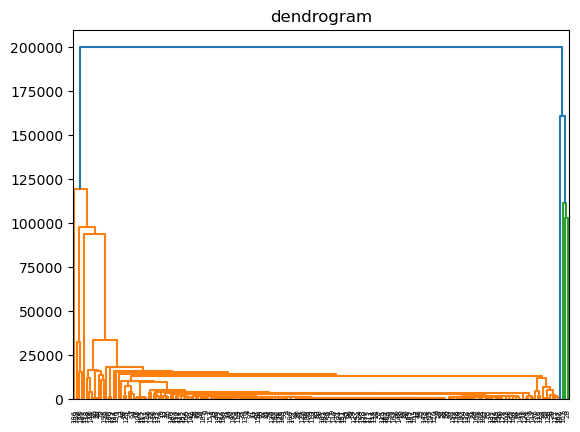

In [11]:
s=sch.dendrogram(sch.linkage(x))
plt.title("dendrogram")
plt.show()

In [12]:
from sklearn.cluster import AgglomerativeClustering

In [13]:
cm=AgglomerativeClustering(n_clusters=5,linkage="ward")
y_pred=cm.fit_predict(x)

In [ ]:
plt.scatter(x.iloc[:,0],x.iloc[:,1],c=y_pred,cmap="rainbow")
plt.legend()
plt.xlabel("accou")
plt.ylabel("spending")
plt.show()